In [ ]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer # Import SimpleImputer

import warnings
warnings.filterwarnings("ignore")

# **A. Given your assigned dataset below, model a Simple Linear Regression:**

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/linear-m02.csv")
df

,X,Y
0,26.702827,107.300877
1,87.862999,311.338166
2,79.742602,291.769926
3,65.845183,237.408745
4,85.058173,321.865779
...,...,...
495,92.700097,338.342488
496,53.995713,184.135584
497,84.203329,278.311203
498,52.095798,180.099910


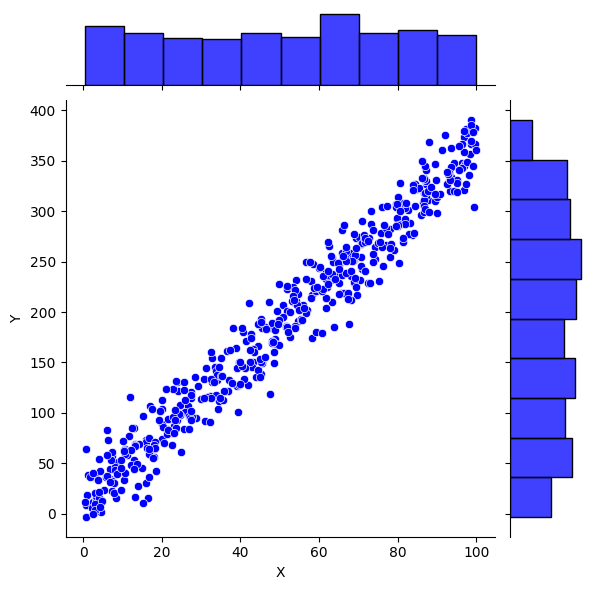

In [ ]:
sns.jointplot(x='X', y='Y', data = df, color = 'blue')

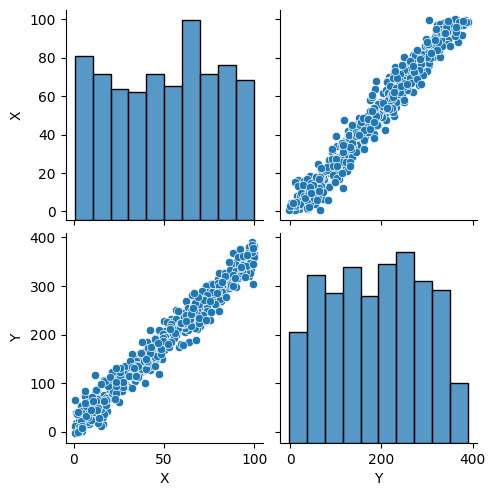

In [ ]:
sns.pairplot(df)

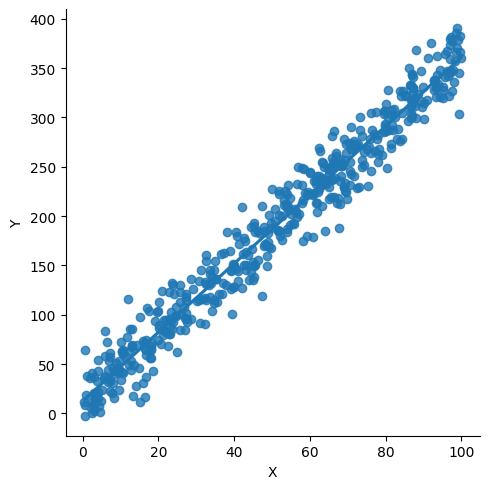

In [ ]:
sns.lmplot(x='X', y='Y', data=df)

In [ ]:
# Training and testting of dataset
y = df['Y']
X = df[['X']]

In [ ]:
X

,X
0,26.702827
1,87.862999
2,79.742602
3,65.845183
4,85.058173
...,...
495,92.700097
496,53.995713
497,84.203329
498,52.095798


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state = 101)

In [ ]:
X_train.shape

(375, 1)

In [ ]:
model = LinearRegression(fit_intercept = True)

In [ ]:
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
print('Linear Model Coefficient (m): ', model.coef_)
print('Linear Model Coefficient (b): ', model.intercept_)

Linear Model Coefficient (m):  [3.48386493]
Linear Model Coefficient (b):  12.762986310493233


In [ ]:
y_predict = model.predict(X_test)
y_predict

array([129.51386866, 151.70745624, 333.57393852, 309.09417185,
        23.76717253, 222.99632541, 284.45058854,  26.73648684,
       235.21680185, 305.35932015, 289.88700844, 207.0871949 ,
        77.39757007, 313.5367687 , 360.14769392, 337.46898929,
       345.65453564,  69.73249479,  49.89855831, 203.22498061,
        68.0188627 , 317.05184506, 245.08948625,  58.35760198,
       126.05481232, 112.00885755, 125.42127075, 360.94522921,
       108.09082095, 164.51432973, 271.79122018, 244.02351767,
       137.91504001, 356.84675405,  89.13417856, 348.99730421,
       200.88659898,  42.60516348, 239.51987023,  75.81291216,
       247.08847941, 148.94935528, 204.45448164,  23.60968026,
       337.09293742, 277.89346554, 319.37065312, 254.06451271,
       183.07053198, 193.12673009, 298.15732008, 180.16511649,
        95.5198722 , 290.57544134,  80.96939213, 224.26634841,
       281.34174408, 330.61805256, 359.8722651 , 162.87837952,
       263.32317154, 160.99911686, 338.92668741, 160.38

In [ ]:
y_test

,Y
18,145.673129
361,128.237315
104,375.442911
4,321.865779
156,17.712716
...,...
143,154.169573
271,362.350657
56,278.365468
475,229.115021


Text(0.5, 1.0, 'Simple Linear Regression of linear-m02.csv (training dataset)')

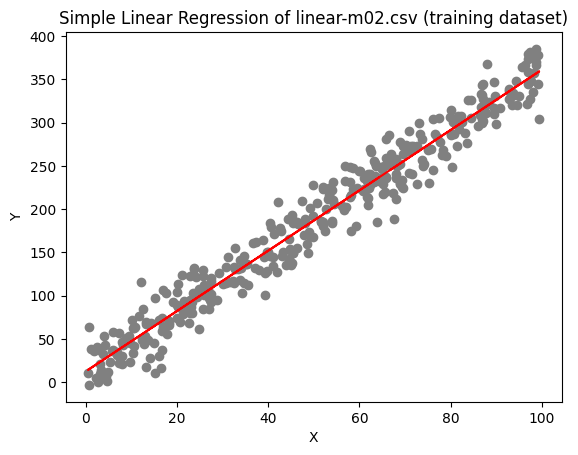

In [ ]:
plt.scatter(X_train, y_train, color = 'gray')
plt.plot(X_train, model.predict(X_train), color = 'red')
plt.ylabel('Y')
plt.xlabel('X')
plt.title('Simple Linear Regression of linear-m02.csv (training dataset)')

Text(0.5, 1.0, 'Simple Linear Regression of linear-m02.csv (test dataset)')

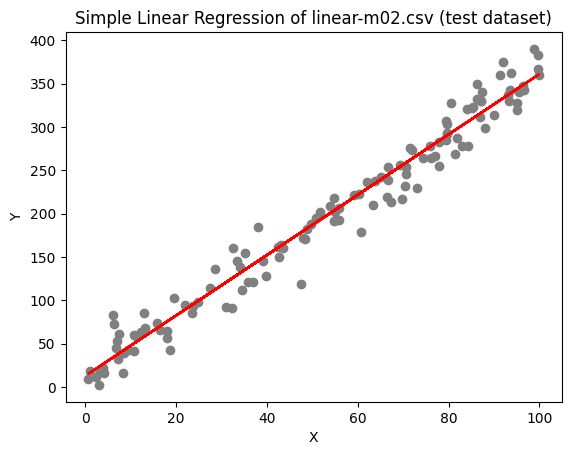

In [ ]:
plt.scatter(X_test, y_test, color = 'gray')
plt.plot(X_test, model.predict(X_test), color = 'red')
plt.ylabel('Y')
plt.xlabel('X')
plt.title('Simple Linear Regression of linear-m02.csv (test dataset)')

In [ ]:
y_predict = model.predict([[12]])
y_predict

array([54.56936546])

# **1. What is the slope of the line? (2 decimal places, no rounding)**

In [ ]:
print('The slope of the line is: ', model.coef_[0])

The slope of the line is:  3.4838649291733614


# **2. What is the RMSE of the model based on test data? (2 decimal places, no rounding)**

In [ ]:
from sklearn import metrics
y_predict_test = model.predict(X_test)
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_predict_test)))

RMSE: 19.139392758345046


# **3. If I have an X value of 38.85, what is the value of Y?**

In [ ]:
x_value = 38.85
predicted_y = model.predict([[x_value]])
print(f"For X = {x_value}, the predicted Y value is: {predicted_y[0]}")

For X = 38.85, the predicted Y value is: 148.11113880887834


# **B. Given your assigned dataset below, identify which model is the most accurate (SVM, DT, RF):**

In [ ]:
dataset = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/classification-f02.csv')
dataset

,A,B,C,Z
0,40.181969,39.828174,43.449460,0
1,16.065769,28.541647,14.831670,1
2,26.029840,26.776941,32.934835,1
3,31.731555,21.483142,40.106356,0
4,34.707991,30.612042,40.819845,0
...,...,...,...,...
495,NaN,NaN,NaN,0
496,NaN,NaN,NaN,0
497,NaN,NaN,NaN,1
498,NaN,NaN,NaN,0


In [ ]:
for col in dataset.columns:
    if dataset[col].isnull().any():
        mean_value = dataset[col].mean()
        dataset[col].fillna(mean_value, inplace=True)

dataset

,A,B,C,Z
0,40.181969,39.828174,43.449460,0
1,16.065769,28.541647,14.831670,1
2,26.029840,26.776941,32.934835,1
3,31.731555,21.483142,40.106356,0
4,34.707991,30.612042,40.819845,0
...,...,...,...,...
495,25.724287,29.032157,29.701277,0
496,25.724287,29.032157,29.701277,0
497,25.724287,29.032157,29.701277,1
498,25.724287,29.032157,29.701277,0


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Assuming the last column is the target variable
X_clf = dataset.drop(dataset.columns[-1], axis=1)
y_clf = dataset[dataset.columns[-1]]

In [ ]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.25, random_state=101)

In [ ]:
# Scale features for SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clf)
X_test_scaled = scaler.transform(X_test_clf)

In [ ]:
# Train and evaluate SVM
svm_model = SVC(random_state=101)
svm_model.fit(X_train_scaled, y_train_clf)
svm_predictions = svm_model.predict(X_test_scaled)
svm_accuracy = accuracy_score(y_test_clf, svm_predictions)
print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.992


In [ ]:
# Train and evaluate Decision Tree
dt_model = DecisionTreeClassifier(random_state=101)
dt_model.fit(X_train_clf, y_train_clf)
dt_predictions = dt_model.predict(X_test_clf)
dt_accuracy = accuracy_score(y_test_clf, dt_predictions)
print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.976


In [ ]:
# Train and evaluate Random Forest
rf_model = RandomForestClassifier(random_state=101)
rf_model.fit(X_train_clf, y_train_clf)
rf_predictions = rf_model.predict(X_test_clf)
rf_accuracy = accuracy_score(y_test_clf, rf_predictions)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.984


# **4. What is the best model based on accuracy results? (SVM, DT, RF)**

In [ ]:
# Determine the most accurate model
accuracies = {
    "SVM": svm_accuracy,
    "Decision Tree": dt_accuracy,
    "Random Forest": rf_accuracy
}

most_accurate_model = max(accuracies, key=accuracies.get)
print(f"The most accurate model is: {most_accurate_model} with an accuracy of {accuracies[most_accurate_model]:.4f}")

The most accurate model is: SVM with an accuracy of 0.9920


# **5. If your best model is SVM, what is the optimized value of C?**

In [ ]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.25, random_state=101)

In [ ]:
# Prepare the data
X = dataset.iloc[:, :-1]  # All columns except the last one
y = dataset.iloc[:, -1]   # Last column is the target

# Handle missing values using imputation
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
X = imputer.fit_transform(X) # Impute missing values in X

# Since imputation converts to numpy array, convert back to DataFrame if needed for clarity,
# though StandardScaler and train_test_split can handle numpy arrays.
X = pd.DataFrame(X, columns=dataset.columns[:-1])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)

# Scale the data for SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SVM with Grid Search
svm_param_grid = {
    'C': [0.01, 0.05, 0.1, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5],
    'kernel': ['linear', 'rbf', 'poly']
}
svm_grid = GridSearchCV(SVC(), svm_param_grid, cv=5, scoring='accuracy')
svm_grid.fit(X_train_scaled, y_train)
svm_best = svm_grid.best_estimator_
svm_pred = svm_best.predict(X_test_scaled)
svm_accuracy = accuracy_score(y_test, svm_pred)

# Print results
print(f"Optimized value of C: {svm_grid.best_params_['C']}")

Optimized value of C: 0.5


# **6. If your best model is SVM, what is the best kernel?**

In [ ]:
# Define the parameter grid for kernel
param_grid_kernel = {'kernel': ['linear', 'poly', 'rbf', 'sigmoid']}
# Create the GridSearchCV object for kernel tuning
grid_kernel = GridSearchCV(SVC(), param_grid_kernel, refit=True, verbose=3)
# Fit the grid search to the scaled training data
grid_kernel.fit(X_train_scaled, y_train_clf)
# Print the best parameters found by the grid search
print("\nBest kernel for SVM:", grid_kernel.best_params_['kernel'])

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV 1/5] END .....................kernel=linear;, score=1.000 total time=   0.0s
[CV 2/5] END .....................kernel=linear;, score=0.987 total time=   0.0s
[CV 3/5] END .....................kernel=linear;, score=0.960 total time=   0.0s
[CV 4/5] END .....................kernel=linear;, score=1.000 total time=   0.0s
[CV 5/5] END .....................kernel=linear;, score=0.987 total time=   0.0s
[CV 1/5] END .......................kernel=poly;, score=0.987 total time=   0.0s
[CV 2/5] END .......................kernel=poly;, score=0.987 total time=   0.0s
[CV 3/5] END .......................kernel=poly;, score=0.947 total time=   0.0s
[CV 4/5] END .......................kernel=poly;, score=0.973 total time=   0.0s
[CV 5/5] END .......................kernel=poly;, score=0.973 total time=   0.0s
[CV 1/5] END ........................kernel=rbf;, score=1.000 total time=   0.0s
[CV 2/5] END ........................kernel=rbf;,

# **7. What is your prediction for this data (0 or 1)? [30, 25, 35]**
# **param_grid = {'C': [0.01, 0.05, 0.1, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5], 'kernel': ['linear', 'rbf', 'poly']}**
   * If you need to scale the data on SVM, use a Standard Scaler

In [ ]:
param_grid_specified = {'C': [0.01, 0.05, 0.1, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5],
                        'kernel': ['linear', 'rbf', 'poly']}

# Create the GridSearchCV object with the specified param_grid
grid_specified = GridSearchCV(SVC(), param_grid_specified, refit=True, verbose=3)

# Fit the grid search to the scaled training data
grid_specified.fit(X_train_scaled, y_train_clf)

# Use the best estimator found by GridSearchCV for prediction
best_svm_model = grid_specified.best_estimator_

# The new data point is [30, 25, 35].
# This data point needs to be scaled using the same scaler fitted on the training data.
new_data_point = np.array([[30, 25, 35]])
new_data_point_scaled = scaler.transform(new_data_point)

# Make the prediction
prediction = best_svm_model.predict(new_data_point_scaled)

print(f"\nThe prediction for the data point [30, 25, 35] is: {prediction[0]}")

Fitting 5 folds for each of 39 candidates, totalling 195 fits
[CV 1/5] END .............C=0.01, kernel=linear;, score=1.000 total time=   0.0s
[CV 2/5] END .............C=0.01, kernel=linear;, score=0.987 total time=   0.0s
[CV 3/5] END .............C=0.01, kernel=linear;, score=0.960 total time=   0.0s
[CV 4/5] END .............C=0.01, kernel=linear;, score=0.987 total time=   0.0s
[CV 5/5] END .............C=0.01, kernel=linear;, score=0.987 total time=   0.0s
[CV 1/5] END ................C=0.01, kernel=rbf;, score=1.000 total time=   0.0s
[CV 2/5] END ................C=0.01, kernel=rbf;, score=0.987 total time=   0.0s
[CV 3/5] END ................C=0.01, kernel=rbf;, score=0.960 total time=   0.0s
[CV 4/5] END ................C=0.01, kernel=rbf;, score=0.987 total time=   0.0s
[CV 5/5] END ................C=0.01, kernel=rbf;, score=1.000 total time=   0.0s
[CV 1/5] END ...............C=0.01, kernel=poly;, score=0.933 total time=   0.0s
[CV 2/5] END ...............C=0.01, kernel=poly